# EEG + ECG EDA on eegmat (36 subjects)

Rest vs mental arithmetic task. Looks at EEG band power, ECG heart rate / HRV, and how the two relate, using every subject. Data is read from Google Drive.

## Setup

In [ ]:
!pip install mne pandas matplotlib seaborn scipy neurokit2 -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/NeuroPredict/eegmat_extracted/eeg-during-mental-arithmetic-tasks-1.0.0"
import os
print(os.listdir(base_path)[:5])

Mounted at /content/drive
['Subject29_2.edf', 'Subject24_1.edf', 'Subject12_2.edf', 'Subject02_2.edf', 'Subject15_1.edf']


In [ ]:
import mne
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy import stats as sstats
import neurokit2 as nk

mne.set_log_level('WARNING')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

edf_files = sorted(glob.glob(os.path.join(base_path, 'Subject*_*.edf')))
print(f'Found {len(edf_files)} edf files')

Found 72 edf files


## Helper functions

In [ ]:
BANDS = {
    'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 40),
}

def parse_subject_condition(filepath):
    fname = os.path.basename(filepath)
    m = re.match(r'(Subject\d+)_(\d)\.edf', fname, re.IGNORECASE)
    subject, cond_code = m.group(1), m.group(2)
    condition = 'rest' if cond_code == '1' else 'task'
    return subject, condition

def load_full(filepath):
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
    raw.filter(l_freq=1.0, h_freq=40.0, verbose=False, picks='eeg')
    eeg_chs = [ch for ch in raw.ch_names if 'ECG' not in ch.upper()]
    ecg_chs = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]
    return raw, eeg_chs, ecg_chs

def band_power_per_channel(raw, eeg_chs):
    data = raw.get_data(picks=eeg_chs)
    sfreq = raw.info['sfreq']
    out = {}
    for i, ch in enumerate(eeg_chs):
        freqs, psd = welch(data[i], fs=sfreq, nperseg=min(int(sfreq*2), len(data[i])))
        out[ch] = {}
        for band, (lo, hi) in BANDS.items():
            idx = np.logical_and(freqs >= lo, freqs <= hi)
            out[ch][band] = np.mean(psd[idx])
    return out

def ecg_hrv_features(raw, ecg_chs):
    if len(ecg_chs) == 0:
        return None
    sig = raw.get_data(picks=ecg_chs)[0]
    sfreq = raw.info['sfreq']
    try:
        signals, info = nk.ecg_process(sig, sampling_rate=sfreq)
        hrv_time = nk.hrv_time(info, sampling_rate=sfreq)
        hrv_freq = nk.hrv_frequency(info, sampling_rate=sfreq)
        return {
            'mean_HR_bpm': signals['ECG_Rate'].mean(),
            'SDNN_ms': hrv_time['HRV_SDNN'].iloc[0],
            'RMSSD_ms': hrv_time['HRV_RMSSD'].iloc[0],
            'pNN50': hrv_time['HRV_pNN50'].iloc[0],
            'LF_HF_ratio': hrv_freq['HRV_LFHF'].iloc[0],
        }
    except Exception:
        return None

## Extract features from all files

36 subjects x 2 conditions = 72 files, takes a few minutes.

In [ ]:
eeg_rows = []
ecg_rows = []

for fp in edf_files:
    subject, condition = parse_subject_condition(fp)
    raw, eeg_chs, ecg_chs = load_full(fp)

    bp = band_power_per_channel(raw, eeg_chs)
    for ch, bands in bp.items():
        row = {'subject': subject, 'condition': condition, 'channel': ch}
        row.update(bands)
        eeg_rows.append(row)

    hrv = ecg_hrv_features(raw, ecg_chs)
    if hrv is not None:
        hrv_row = {'subject': subject, 'condition': condition}
        hrv_row.update(hrv)
        ecg_rows.append(hrv_row)

    print(f'{subject} ({condition}) done - EEG channels: {len(eeg_chs)}, ECG found: {len(ecg_chs) > 0}')

df_eeg = pd.DataFrame(eeg_rows)
df_ecg = pd.DataFrame(ecg_rows)

print('\ndf_eeg shape:', df_eeg.shape)
print('df_ecg shape:', df_ecg.shape)

Subject00 (rest) done - EEG channels: 20, ECG found: True
Subject00 (task) done - EEG channels: 20, ECG found: True
Subject01 (rest) done - EEG channels: 20, ECG found: True
Subject01 (task) done - EEG channels: 20, ECG found: True
Subject02 (rest) done - EEG channels: 20, ECG found: True
Subject02 (task) done - EEG channels: 20, ECG found: True
Subject03 (rest) done - EEG channels: 20, ECG found: True
Subject03 (task) done - EEG channels: 20, ECG found: True
Subject04 (rest) done - EEG channels: 20, ECG found: True
Subject04 (task) done - EEG channels: 20, ECG found: True
Subject05 (rest) done - EEG channels: 20, ECG found: True
Subject05 (task) done - EEG channels: 20, ECG found: True
Subject06 (rest) done - EEG channels: 20, ECG found: True
Subject06 (task) done - EEG channels: 20, ECG found: True
Subject07 (rest) done - EEG channels: 20, ECG found: True
Subject07 (task) done - EEG channels: 20, ECG found: True
Subject08 (rest) done - EEG channels: 20, ECG found: True
Subject08 (tas

## EEG band power: rest vs task

In [ ]:
band_cols = list(BANDS.keys())
overall = df_eeg.groupby('condition')[band_cols].mean()
print('Average band power, rest vs task:')
print(overall)

pct_change = ((overall.loc['task'] - overall.loc['rest']) / overall.loc['rest'] * 100).round(2)
print('\n% change (task vs rest):')
print(pct_change)

Average band power, rest vs task :
                  delta         theta         alpha          beta  \
condition                                                           
rest       1.117704e-11  3.884822e-12  6.918015e-12  6.999009e-13   
task       1.250454e-11  3.331584e-12  4.576274e-12  6.103426e-13   

                  gamma  
condition                
rest       1.143302e-13  
task       1.365121e-13  

% change (task vs rest):
delta    11.88
theta   -14.24
alpha   -33.85
beta    -12.80
gamma    19.40
dtype: float64


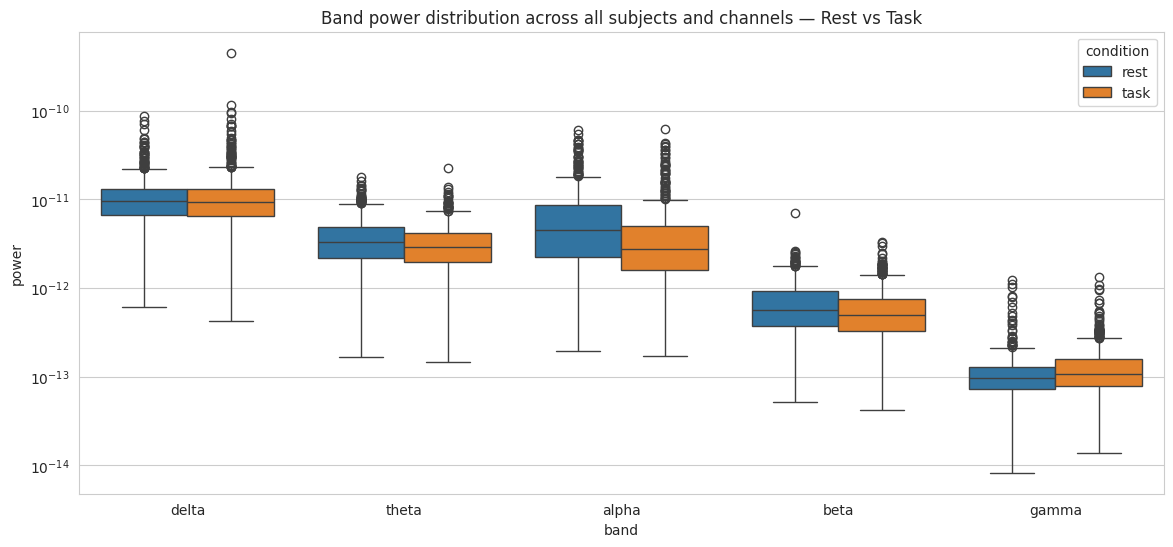

In [ ]:
eeg_melt = df_eeg.melt(id_vars=['subject','condition','channel'], value_vars=band_cols,
                        var_name='band', value_name='power')
plt.figure(figsize=(14,6))
sns.boxplot(data=eeg_melt, x='band', y='power', hue='condition')
plt.yscale('log')
plt.title('Band power across all subjects and channels (rest vs task)')
plt.show()

## EEG paired t-test per band

In [ ]:
subject_band_avg = df_eeg.groupby(['subject','condition'])[band_cols].mean().reset_index()

print('Paired t-test results (Rest vs Task), per band:')
print('='*60)
for band in band_cols:
    rest_vals = subject_band_avg[subject_band_avg['condition']=='rest'].sort_values('subject')[band].values
    task_vals = subject_band_avg[subject_band_avg['condition']=='task'].sort_values('subject')[band].values
    t_stat, p_val = sstats.ttest_rel(rest_vals, task_vals)
    sig = 'SIGNIFICANT (p<0.05)' if p_val < 0.05 else 'not significant'
    print(f'{band:8s} | t={t_stat:7.3f} | p={p_val:.5f} | {sig}')

Paired t-test results (Rest vs Task), per band:
delta    | t= -1.100 | p=0.27864 | not significant
theta    | t=  2.759 | p=0.00916 | SIGNIFICANT (p<0.05)
alpha    | t=  4.665 | p=0.00004 | SIGNIFICANT (p<0.05)
beta     | t=  4.392 | p=0.00010 | SIGNIFICANT (p<0.05)
gamma    | t= -3.232 | p=0.00268 | SIGNIFICANT (p<0.05)


## EEG regional check

Expected: alpha drops over occipital/parietal and theta rises over frontal during the task.

In [ ]:
def strip_prefix(ch):
    return re.sub(r'^(EEG|ECG)\s+', '', ch, flags=re.IGNORECASE)

occ_par = ['O1','O2','P3','P4','Pz']
frontal = ['Fp1','Fp2','F3','F4','F7','F8','Fz']

df_eeg['region_ch'] = df_eeg['channel'].apply(strip_prefix)

occ_par_df = df_eeg[df_eeg['region_ch'].isin(occ_par)]
frontal_df = df_eeg[df_eeg['region_ch'].isin(frontal)]

occ_par_alpha = occ_par_df.groupby('condition')['alpha'].mean()
frontal_theta = frontal_df.groupby('condition')['theta'].mean()

alpha_change = (occ_par_alpha['task'] - occ_par_alpha['rest']) / occ_par_alpha['rest'] * 100
theta_change = (frontal_theta['task'] - frontal_theta['rest']) / frontal_theta['rest'] * 100

print(f'Occipital/Parietal Alpha change (task vs rest): {alpha_change:.2f}%  (expect: negative/suppression)')
print(f'Frontal Theta change (task vs rest): {theta_change:.2f}%  (expect: positive/rise)')

Occipital/Parietal Alpha change (task vs rest): -37.41%  (expect: negative/suppression)
Frontal Theta change (task vs rest): 7.35%  (expect: positive/rise)


## EEG per-subject alpha change

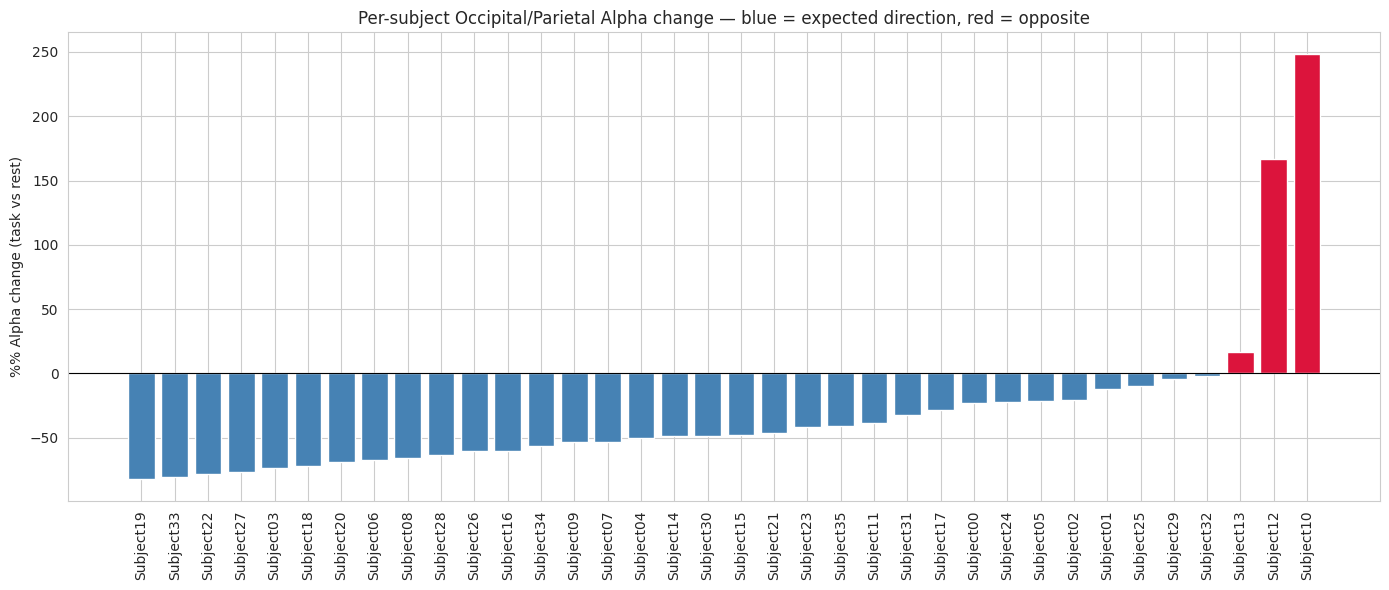

33/36 subjects show the expected (suppression) direction


In [ ]:
subject_alpha_change = []
for subj in df_eeg['subject'].unique():
    sub_occ = occ_par_df[occ_par_df['subject']==subj]
    rest_a = sub_occ[sub_occ['condition']=='rest']['alpha'].mean()
    task_a = sub_occ[sub_occ['condition']=='task']['alpha'].mean()
    if rest_a > 0:
        pct = (task_a - rest_a) / rest_a * 100
        subject_alpha_change.append({'subject': subj, 'alpha_change_pct': pct})

df_subj_change = pd.DataFrame(subject_alpha_change).sort_values('alpha_change_pct')

plt.figure(figsize=(14,6))
colors = ['crimson' if v > 0 else 'steelblue' for v in df_subj_change['alpha_change_pct']]
plt.bar(df_subj_change['subject'], df_subj_change['alpha_change_pct'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90)
plt.ylabel('% alpha change (task vs rest)')
plt.title('Per-subject occipital/parietal alpha change (blue = decrease, red = increase)')
plt.tight_layout()
plt.show()

n_expected = (df_subj_change['alpha_change_pct'] < 0).sum()
print(f'{n_expected}/{len(df_subj_change)} subjects show alpha suppression')

## ECG heart rate and HRV

In [ ]:
print(f'ECG successfully extracted for {df_ecg["subject"].nunique()} out of 36 subjects')

ecg_summary = df_ecg.groupby('condition')[['mean_HR_bpm','SDNN_ms','RMSSD_ms']].agg(['mean','std'])
print(ecg_summary)

ECG successfully extracted for 36 out of 36 subjects
          mean_HR_bpm                SDNN_ms                RMSSD_ms  \
                 mean        std        mean         std        mean   
condition                                                              
rest        73.848904  13.725211  141.985196  303.380151  173.069994   
task        86.565902  18.889026  125.608041  232.569304  135.597432   

                       
                  std  
condition              
rest       443.451102  
task       273.500630  


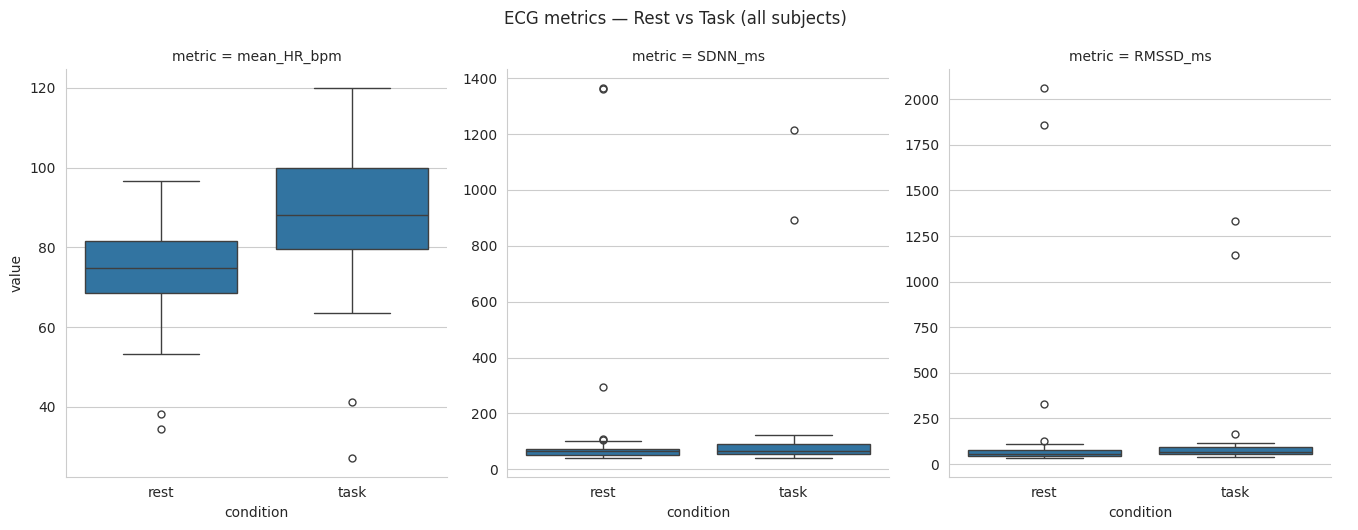

In [ ]:
ecg_melt = df_ecg.melt(id_vars=['subject','condition'], value_vars=['mean_HR_bpm','SDNN_ms','RMSSD_ms'],
                        var_name='metric', value_name='value')
g = sns.catplot(data=ecg_melt, x='condition', y='value', col='metric', kind='box',
                 sharey=False, height=5, aspect=0.9)
g.fig.suptitle('ECG metrics, rest vs task', y=1.05)
plt.show()

## ECG paired t-test

In [ ]:
print('Paired t-test results (Rest vs Task), ECG metrics:')
print('='*60)
for metric in ['mean_HR_bpm','SDNN_ms','RMSSD_ms']:
    paired = df_ecg.pivot(index='subject', columns='condition', values=metric).dropna()
    t_stat, p_val = sstats.ttest_rel(paired['rest'], paired['task'])
    sig = 'SIGNIFICANT (p<0.05)' if p_val < 0.05 else 'not significant'
    print(f'{metric:15s} | n={len(paired):2d} | t={t_stat:7.3f} | p={p_val:.5f} | {sig}')

Paired t-test results (Rest vs Task), ECG metrics:
mean_HR_bpm     | n=36 | t= -4.128 | p=0.00022 | SIGNIFICANT (p<0.05)
SDNN_ms         | n=36 | t=  0.249 | p=0.80481 | not significant
RMSSD_ms        | n=36 | t=  0.420 | p=0.67703 | not significant


## EEG-ECG correlation

Do subjects with a bigger heart rate change also show a bigger alpha change?

36 subjects have both EEG-alpha-change and HR-change data

Pearson correlation (EEG alpha change vs HR change): r=0.071, p=0.6792
Result: not significant


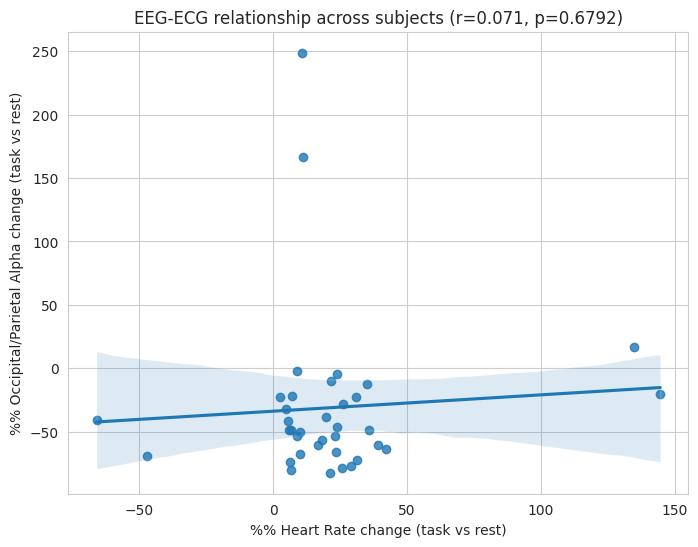

In [ ]:
hr_change_rows = []
for subj in df_ecg['subject'].unique():
    paired = df_ecg[df_ecg['subject']==subj].set_index('condition')
    if 'rest' in paired.index and 'task' in paired.index:
        hr_rest = paired.loc['rest','mean_HR_bpm']
        hr_task = paired.loc['task','mean_HR_bpm']
        hr_change_rows.append({'subject': subj, 'hr_change_pct': (hr_task-hr_rest)/hr_rest*100})

df_hr_change = pd.DataFrame(hr_change_rows)

df_combined = df_subj_change.merge(df_hr_change, on='subject', how='inner')
print(f'{len(df_combined)} subjects have both alpha change and HR change')

r, p = sstats.pearsonr(df_combined['alpha_change_pct'], df_combined['hr_change_pct'])
print(f'\nPearson r (alpha change vs HR change): r={r:.3f}, p={p:.4f}')
print('Result:', 'significant' if p < 0.05 else 'not significant')

plt.figure(figsize=(8,6))
sns.regplot(data=df_combined, x='hr_change_pct', y='alpha_change_pct')
plt.xlabel('% heart rate change (task vs rest)')
plt.ylabel('% occipital/parietal alpha change (task vs rest)')
plt.title(f'EEG vs ECG change across subjects (r={r:.3f}, p={p:.4f})')
plt.show()

## Combined feature table

In [ ]:
region_map = {'occ_par': occ_par, 'frontal': frontal}

feature_rows = []
for subj in df_eeg['subject'].unique():
    for cond in ['rest', 'task']:
        row = {'subject': subj, 'condition': cond}
        sub_df = df_eeg[(df_eeg['subject']==subj) & (df_eeg['condition']==cond)]
        for region_name, chs in region_map.items():
            region_df = sub_df[sub_df['region_ch'].isin(chs)]
            for band in band_cols:
                row[f'{region_name}_{band}'] = region_df[band].mean()
        ecg_row = df_ecg[(df_ecg['subject']==subj) & (df_ecg['condition']==cond)]
        if len(ecg_row) > 0:
            row['mean_HR_bpm'] = ecg_row['mean_HR_bpm'].values[0]
            row['SDNN_ms'] = ecg_row['SDNN_ms'].values[0]
            row['RMSSD_ms'] = ecg_row['RMSSD_ms'].values[0]
        feature_rows.append(row)

df_features_final = pd.DataFrame(feature_rows)
print('Final combined feature table shape:', df_features_final.shape)
df_features_final.head(10)

Final combined feature table shape: (72, 15)


,subject,condition,occ_par_delta,occ_par_theta,occ_par_alpha,occ_par_beta,occ_par_gamma,frontal_delta,frontal_theta,frontal_alpha,frontal_beta,frontal_gamma,mean_HR_bpm,SDNN_ms,RMSSD_ms
0,Subject00,rest,1.011439e-11,3.734056e-12,1.866513e-11,1.439157e-12,1.193894e-13,1.269401e-11,3.777391e-12,8.636924e-12,1.021749e-12,1.594359e-13,76.060844,39.754529,33.962311
1,Subject00,task,1.045898e-11,3.454497e-12,1.441254e-11,1.397513e-12,1.661171e-13,2.022515e-11,3.709217e-12,8.375838e-12,1.117665e-12,2.003822e-13,99.738008,46.577625,59.376219
2,Subject01,rest,1.984760e-11,3.500173e-12,6.841462e-12,1.330960e-12,1.471648e-13,8.895867e-12,3.219388e-12,2.866361e-12,8.057219e-13,1.318201e-13,88.803561,56.238254,40.559063
3,Subject01,task,1.312138e-10,6.786515e-12,5.994943e-12,1.639512e-12,2.661437e-13,2.332344e-11,7.184953e-12,2.868196e-12,7.200321e-13,1.787513e-13,119.999128,92.553345,90.539310
4,Subject02,rest,2.195412e-11,4.127372e-12,1.169382e-11,1.448905e-12,2.656523e-13,1.747995e-11,3.529816e-12,5.569857e-12,1.776698e-12,6.462834e-13,38.253725,1361.263733,2062.755924
5,Subject02,task,1.216111e-11,2.578019e-12,9.287069e-12,1.959993e-12,3.229562e-13,1.125663e-11,2.316291e-12,3.353767e-12,1.265341e-12,5.728113e-13,93.582418,47.825715,61.980920
6,Subject03,rest,1.063774e-11,6.213710e-12,2.006973e-11,9.643844e-13,1.205272e-13,1.089409e-11,3.669467e-12,6.449952e-12,6.026224e-13,1.130111e-13,62.224173,72.497578,89.415786
7,Subject03,task,8.522805e-12,3.488318e-12,5.304528e-12,5.333199e-13,8.161802e-14,1.024964e-11,1.941269e-12,1.916069e-12,2.802583e-13,6.703469e-14,66.136647,73.578476,93.831928
8,Subject04,rest,3.152256e-11,8.495403e-12,1.590661e-11,1.660859e-12,1.615576e-13,3.496657e-11,8.007972e-12,4.788566e-12,1.475593e-12,1.531247e-13,79.653356,90.219971,82.224040
9,Subject04,task,1.642558e-11,6.618096e-12,7.892415e-12,1.731219e-12,1.012591e-13,2.646106e-11,7.804776e-12,3.631647e-12,1.236723e-12,9.727424e-14,87.571871,62.429358,63.444790


In [ ]:
out_dir = os.path.join(base_path, 'eda_outputs')
os.makedirs(out_dir, exist_ok=True)

df_eeg.to_csv(os.path.join(out_dir, 'full_eeg_band_power_all_subjects.csv'), index=False)
df_ecg.to_csv(os.path.join(out_dir, 'full_ecg_hrv_all_subjects.csv'), index=False)
df_features_final.to_csv(os.path.join(out_dir, 'combined_eeg_ecg_features.csv'), index=False)

print('Saved to:', out_dir)
print(os.listdir(out_dir))

Saved to: /content/drive/MyDrive/NeuroPredict/eegmat_extracted/eeg-during-mental-arithmetic-tasks-1.0.0/eda_outputs
['all_subjects_band_power.csv', 'dataset_wide_avg_band_power.csv', 'per_channel_rest_vs_task.csv', 'file_inventory.csv', 'combined_eeg_ecg_features.csv', 'full_ecg_hrv_all_subjects.csv', 'full_eeg_band_power_all_subjects.csv']
